In [2]:
# Improt libraries for data handling, paths and plotting.

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Find the project root wether the notebook is run from /notebooks or from the main project folder.
project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent

# Load the real 15-minute Sloevnian day-ahead price dataset.
file_path = project_root / "data" / "curated" / "da_prices_si_clean.csv"

da = pd.read_csv(file_path, parse_dates=["timestamp"])

# Keep only the columns needed for spike detection.

da = da[["timestamp", "price_eur_mwh"]].copy()

# Sort by timestamp so rolling callculations use the correct time order.

da = da.sort_values("timestamp").reset_index(drop=True)

# Show basic coverage and structure of the dataset.

print("Rows", len(da))
print("Start:", da["timestamp"].min())
print("End", da["timestamp"].max())
print("Missing prices:", da["price_eur_mwh"].isna().sum())

display(da.head())
display(da.tail())

Rows 8541
Start: 2026-01-01 00:00:00
End 2026-04-01 00:00:00
Missing prices: 0


,timestamp,price_eur_mwh
0,2026-01-01 00:00:00,100.51
1,2026-01-01 00:15:00,94.03
2,2026-01-01 00:30:00,92.01
3,2026-01-01 00:45:00,87.38
4,2026-01-01 01:00:00,94.17


,timestamp,price_eur_mwh
8536,2026-03-31 23:00:00,154.98
8537,2026-03-31 23:15:00,152.89
8538,2026-03-31 23:30:00,149.96
8539,2026-03-31 23:45:00,142.27
8540,2026-04-01 00:00:00,161.93


Rolling z-score is useful because it separates high prices from statistically unusual prices. In electricity markets this distinction matters, since prices naturally vary by hour, weekday, weather conditions, renewable production, outages, and cross-border constraints. A price spike is operationally relevant when it is extreme relative to the recent market regime, not only when it crosses a fixed price threshold. Therefore, rolling z-score is a practical monitoring tool that helps analysts identify abnormal 15-minute intervals for further investigation in forecasting, imbalance exposure, and portfolio risk.

In [3]:
# Define the rolling window for 7 days of 15-minute data.
# 7 days * 24 hours * 4 intervals per hour = 672 intervals.
window = 672

# Allow the rolling calculation to start after at least one normal day of data.
min_periods = 96

# Calculate the rolling 7-day mean price.
da["rolling_mean_7d"] = (
    da["price_eur_mwh"]
    .rolling(window=window, min_periods=min_periods)
    .mean()
)

# Calculate the rolling 7-day standard deviation.
da["rolling_std_7d"] = (
    da["price_eur_mwh"]
    .rolling(window=window, min_periods=min_periods)
    .std()
)

# Avoid division by zero if a rolling window has no volatility.
da["rolling_std_7d"] = da["rolling_std_7d"].replace(0, np.nan)

# Calculate the rolling z-score.
# This tells us how unusual each price is compared with the recent 7-day local price regime.
da["z_score"] = (
    (da["price_eur_mwh"] - da["rolling_mean_7d"]) 
    / da["rolling_std_7d"]
)

# Mark spikes where the absolute z-score is at least 3.
# This captures both very high positive spikes and unusually low / negative price spikes.
da["z_spike"] = da["z_score"].abs() >= 3

# Show how many z-score spikes were detected.
print("Z-score spikes:", da["z_spike"].sum())

display(
    da.loc[da["z_spike"], ["timestamp", "price_eur_mwh", "rolling_mean_7d", "rolling_std_7d", "z_score"]]
    .sort_values("z_score", key=lambda s: s.abs(), ascending=False)
    .head(20)
)

Z-score spikes: 120


,timestamp,price_eur_mwh,rolling_mean_7d,rolling_std_7d,z_score
5831,2026-03-02 17:45:00,317.65,84.448274,39.531460,5.899143
6023,2026-03-04 17:45:00,355.32,87.807693,50.575572,5.289358
5979,2026-03-04 06:45:00,324.13,87.246905,46.051588,5.143864
2139,2026-01-23 06:45:00,400.76,151.312143,50.178911,4.971169
5981,2026-03-04 07:15:00,319.14,87.827723,47.663101,4.853068
2050,2026-01-22 08:30:00,347.10,146.493065,41.434814,4.841507
5980,2026-03-04 07:00:00,310.72,87.537336,46.839054,4.764884
454,2026-01-05 17:30:00,244.39,92.230264,32.227135,4.721479
2047,2026-01-22 07:45:00,331.66,145.907381,39.778355,4.669691
455,2026-01-05 17:45:00,243.18,92.561294,32.958679,4.569925


In [4]:
# Calculate the global 25th percentile price.
q1 = da["price_eur_mwh"].quantile(0.25)

# Calculate the global 75th percentile price.
q3 = da["price_eur_mwh"].quantile(0.75)

# Calculate the interquartile range.
iqr = q3 - q1

# Define the standard IQR outlier boundaries.
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

# Mark IQR spikes outside the global IQR range.
da["iqr_spike"] = (
    (da["price_eur_mwh"] < lower_bound) |
    (da["price_eur_mwh"] > upper_bound)
)

# Compare how many spikes each method finds.
comparison = pd.DataFrame({
    "method": ["Rolling z-score", "Global IQR"],
    "spike_count": [da["z_spike"].sum(), da["iqr_spike"].sum()],
    "share_of_rows_%": [
        da["z_spike"].mean() * 100,
        da["iqr_spike"].mean() * 100
    ]
})

print("IQR lower bound:", round(lower_bound, 2))
print("IQR upper bound:", round(upper_bound, 2))

display(comparison)

IQR lower bound: 26.09
IQR upper bound: 216.73


,method,spike_count,share_of_rows_%
0,Rolling z-score,120,1.404988
1,Global IQR,680,7.961597


The IQR method is a robust way to identify extreme electricity prices compared with the overall distribution of observed prices. Its main advantage is simplicity: it uses percentile-based thresholds and is less distorted by extreme values than mean-based methods. However, because electricity prices are highly regime-dependent, a global IQR threshold does not fully capture whether a price is unusual for a specific hour, weekday, or recent market environment. Therefore, IQR is useful as a baseline outlier method, while rolling z-score is more suitable for market monitoring because it adapts to recent price behavior.

In [5]:
# Classify whether each row is detected by z-score, IQR, both, or neither.
da["spike_method"] = np.select(
    [
        da["z_spike"] & da["iqr_spike"],
        da["z_spike"] & ~da["iqr_spike"],
        ~da["z_spike"] & da["iqr_spike"],
    ],
    [
        "both",
        "z_score_only",
        "iqr_only",
    ],
    default="not_spike"
)

# Count how the two methods overlap.
method_overlap = (
    da["spike_method"]
    .value_counts()
    .rename_axis("spike_method")
    .reset_index(name="row_count")
)

display(method_overlap)

# Show the most extreme detected prices from either method.
display(
    da.loc[
        da["z_spike"] | da["iqr_spike"],
        ["timestamp", "price_eur_mwh", "z_score", "z_spike", "iqr_spike", "spike_method"]
    ]
    .sort_values("price_eur_mwh", ascending=False)
    .head(20)
)

,spike_method,row_count
0,not_spike,7837
1,iqr_only,584
2,both,96
3,z_score_only,24


,timestamp,price_eur_mwh,z_score,z_spike,iqr_spike,spike_method
2139,2026-01-23 06:45:00,400.76,4.971169,True,True,both
1219,2026-01-13 16:45:00,361.20,3.739011,True,True,both
6023,2026-03-04 17:45:00,355.32,5.289358,True,True,both
2143,2026-01-23 07:45:00,352.96,3.914772,True,True,both
2082,2026-01-22 16:30:00,347.72,4.374866,True,True,both
2050,2026-01-22 08:30:00,347.10,4.841507,True,True,both
1221,2026-01-13 17:15:00,340.67,3.325357,True,True,both
2148,2026-01-23 09:00:00,337.93,3.489890,True,True,both
1211,2026-01-13 14:45:00,334.68,3.468049,True,True,both
2083,2026-01-22 16:45:00,333.25,4.020980,True,True,both


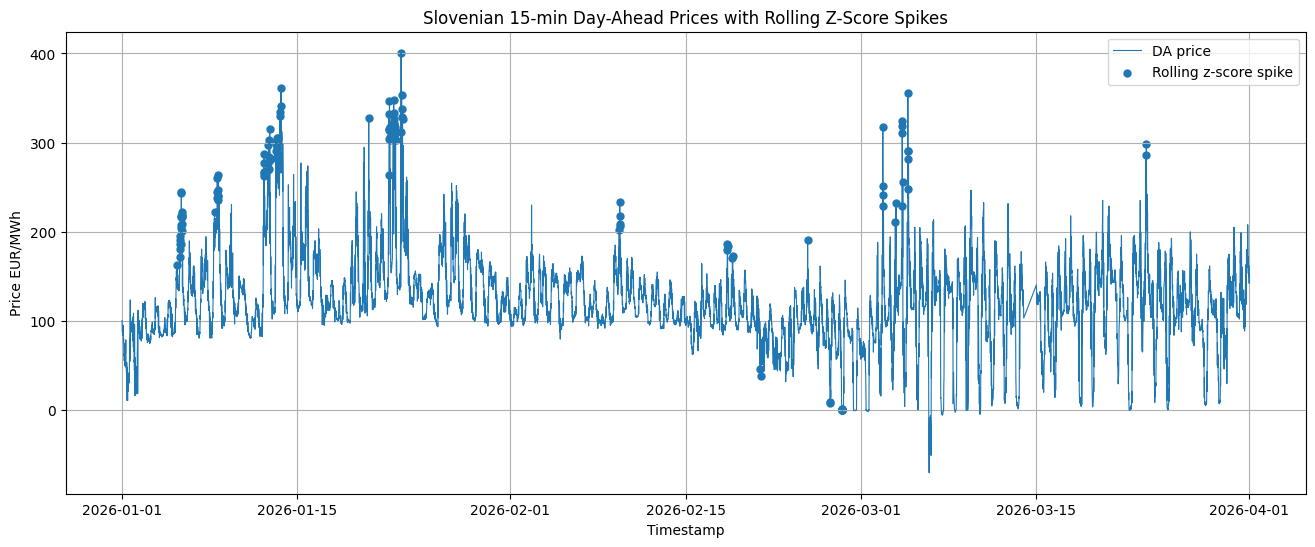

In [6]:
# Plot the full price time series.
plt.figure(figsize=(16, 6))
plt.plot(da["timestamp"], da["price_eur_mwh"], linewidth=0.8, label="DA price")

# Mark rolling z-score spikes.
plt.scatter(
    da.loc[da["z_spike"], "timestamp"],
    da.loc[da["z_spike"], "price_eur_mwh"],
    s=25,
    label="Rolling z-score spike"
)

# Add chart labels.
plt.title("Slovenian 15-min Day-Ahead Prices with Rolling Z-Score Spikes")
plt.xlabel("Timestamp")
plt.ylabel("Price EUR/MWh")
plt.legend()
plt.grid(True)
plt.show()

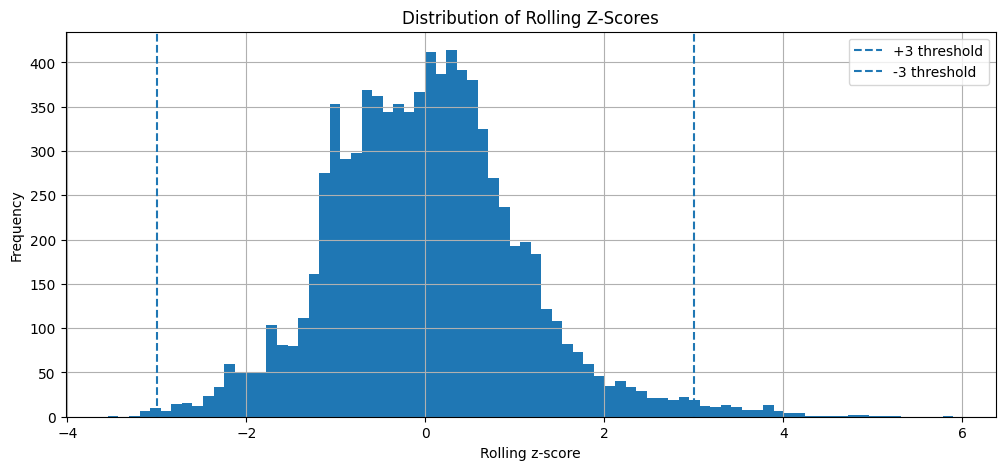

In [7]:
# Plot the distribution of rolling z-scores.
plt.figure(figsize=(12, 5))
plt.hist(da["z_score"].dropna(), bins=80)

# Add threshold lines for common spike detection cutoffs.
plt.axvline(3, linestyle="--", label="+3 threshold")
plt.axvline(-3, linestyle="--", label="-3 threshold")

# Add chart labels.
plt.title("Distribution of Rolling Z-Scores")
plt.xlabel("Rolling z-score")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()

,hour,observations,z_spikes,iqr_spikes,avg_price,z_spike_rate_%,iqr_spike_rate_%
0,0,357,0,1,105.872325,0.000000,0.280112
1,1,356,0,0,102.757079,0.000000,0.000000
2,2,352,0,1,100.968040,0.000000,0.284091
3,3,356,0,1,100.695983,0.000000,0.280899
4,4,356,0,1,103.420084,0.000000,0.280899
5,5,356,0,0,111.793287,0.000000,0.000000
6,6,356,5,11,131.724101,1.404494,3.089888
7,7,356,12,24,144.646011,3.370787,6.741573
8,8,356,11,25,136.821489,3.089888,7.022472
9,9,356,9,43,122.495112,2.528090,12.078652


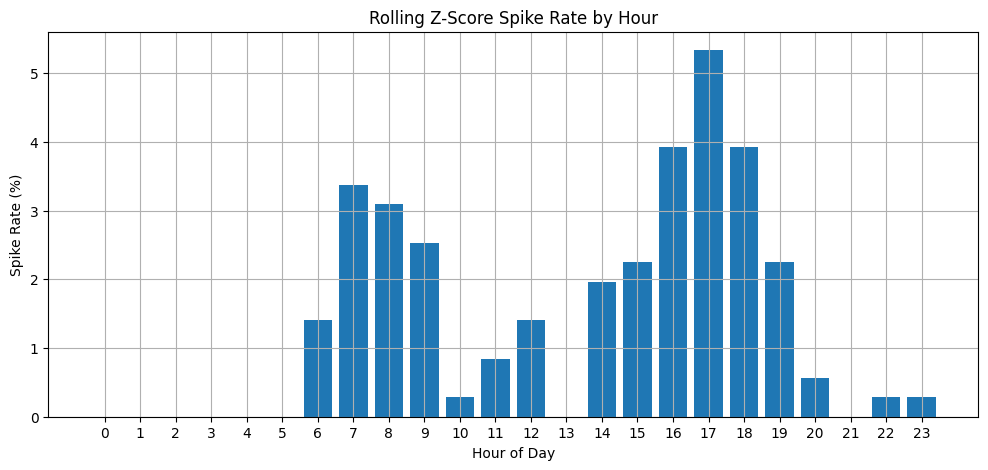

In [8]:
# Extract the hour of day from each timestamp.
da["hour"] = da["timestamp"].dt.hour

# Count observations and spikes by hour.
hourly_spike_pattern = (
    da.groupby("hour")
    .agg(
        observations=("price_eur_mwh", "size"),
        z_spikes=("z_spike", "sum"),
        iqr_spikes=("iqr_spike", "sum"),
        avg_price=("price_eur_mwh", "mean")
    )
    .reset_index()
)

# Calculate spike rates so hours can be compared fairly.
hourly_spike_pattern["z_spike_rate_%"] = (
    hourly_spike_pattern["z_spikes"] 
    / hourly_spike_pattern["observations"] 
    * 100
)

hourly_spike_pattern["iqr_spike_rate_%"] = (
    hourly_spike_pattern["iqr_spikes"] 
    / hourly_spike_pattern["observations"] 
    * 100
)

display(hourly_spike_pattern)

# Plot z-score spike rate by hour.
plt.figure(figsize=(12, 5))
plt.bar(hourly_spike_pattern["hour"], hourly_spike_pattern["z_spike_rate_%"])

plt.title("Rolling Z-Score Spike Rate by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Spike Rate (%)")
plt.xticks(range(0, 24))
plt.grid(True)
plt.show()

,day_of_week,observations,z_spikes,iqr_spikes,avg_price,z_spike_rate_%,iqr_spike_rate_%
0,Monday,1248,43,99,132.255497,3.445513,7.932692
1,Tuesday,1248,15,119,136.181250,1.201923,9.535256
2,Wednesday,1153,15,83,127.359419,1.300954,7.198612
3,Thursday,1248,33,118,127.277508,2.644231,9.455128
4,Friday,1248,14,97,121.604271,1.121795,7.772436
5,Saturday,1152,0,70,105.683238,0.000000,6.076389
6,Sunday,1244,0,94,96.247822,0.000000,7.556270


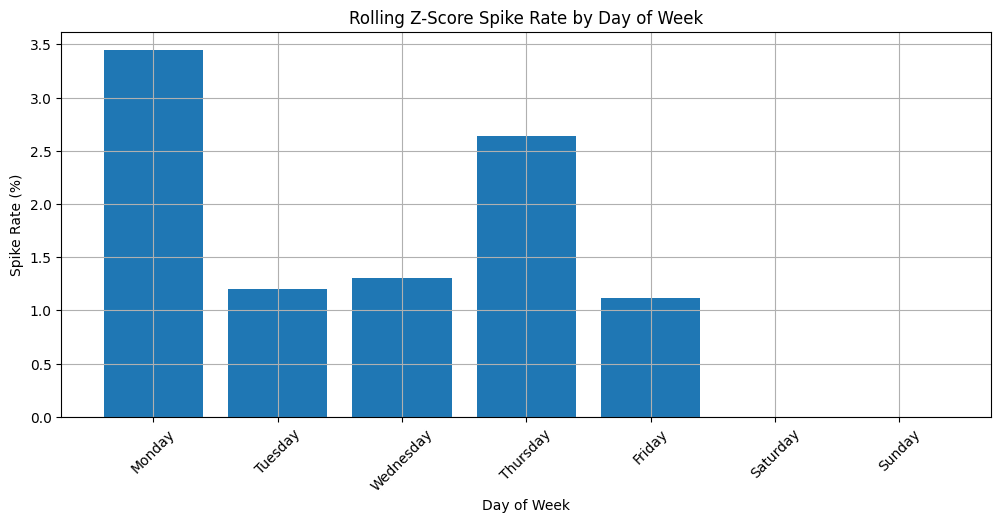

In [9]:
# Extract day of week from each timestamp.
da["day_of_week"] = da["timestamp"].dt.day_name()

# Keep days in calendar order instead of alphabetical order.
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

# Count observations and spikes by day of week.
dow_spike_pattern = (
    da.groupby("day_of_week")
    .agg(
        observations=("price_eur_mwh", "size"),
        z_spikes=("z_spike", "sum"),
        iqr_spikes=("iqr_spike", "sum"),
        avg_price=("price_eur_mwh", "mean")
    )
    .reindex(day_order)
    .reset_index()
)

# Calculate spike rates by day of week.
dow_spike_pattern["z_spike_rate_%"] = (
    dow_spike_pattern["z_spikes"] 
    / dow_spike_pattern["observations"] 
    * 100
)

dow_spike_pattern["iqr_spike_rate_%"] = (
    dow_spike_pattern["iqr_spikes"] 
    / dow_spike_pattern["observations"] 
    * 100
)

display(dow_spike_pattern)

# Plot z-score spike rate by day of week.
plt.figure(figsize=(12, 5))
plt.bar(dow_spike_pattern["day_of_week"], dow_spike_pattern["z_spike_rate_%"])

plt.title("Rolling Z-Score Spike Rate by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Spike Rate (%)")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [ ]:
# Exercise: Compare z-score vs IQR
z_count = int(da["z_spike"].sum())
iqr_count = int(da["iqr_spike"].sum())
both_count = int(((da["z_spike"]) & (da["iqr_spike"])).sum())

print(f"Rolling z-score spikes: {z_count}")
print(f"IQR spikes: {iqr_count}")
print(f"Detected by both methods: {both_count}")

Rolling z-score spikes: 120
IQR spikes: 680
Detected by both methods: 96


The rolling z-score method is more appropriate for electricity prices because it compares each 15-minute price against the recent 7-day local price regime instead of using one fixed threshold for the whole dataset. Electricity prices are volatile, seasonal, and strongly affected by hour-of-day and weekday patterns, so a global IQR threshold can miss context-specific spikes or overlabel normal high-price periods. The IQR method is still useful as a simple benchmark because it is easy to explain and does not rely on standard deviation. However, for operational electricity-market analysis, the rolling z-score gives a better view of whether a price is unusual relative to recent market conditions.